<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/DS-AI-Project/blob/main/DataProcess%20%26%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tập dữ liệu của dự án này chỉ lấy dữ liệu của thành phố có ID 03 từ tập dữ liệu train 4.5M rows. Vì dữ liệu tổng quá lớn nên chỉ thực hiện ở 1 quy mô dữ liệu nhỏ hơn.

**PHASE 1 (DATA INGESTION & OVERVIEW)**

In [20]:
from datasets import load_dataset
import pandas as pd

# 1. Tải dataset
print("Đang tải dữ liệu về máy...")
dataset = load_dataset("Dingdong-Inc/FreshRetailNet-50K", split='train')
# 2. Lọc dữ liệu bằng bộ lọc của dataset
print("Đang lọc City ID 3...")
df_city_3 = dataset.filter(lambda example: example['city_id'] == 3)
print(f"Đã hoàn thành! Có {len(df_city_3)} dòng dữ liệu cho City ID 3.")

Đang tải dữ liệu về máy...
Đang lọc City ID 3...
Đã hoàn thành! Có 238320 dòng dữ liệu cho City ID 3.


Overview

In [22]:
# Convert to Pandas DataFrame for data processing
print("\nConverting to Pandas DataFrame...")
df_city_3 = df_city_3.to_pandas()

# Check size and preview data
print(f"Dataset size: {df_city_3.shape}")
df_city_3.head()


Converting to Pandas DataFrame...
Dataset size: (238320, 19)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,3,70,0,5,6,65,157,2024-03-28,1.80,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.7, 1.1, 0.0, ...",15,"[1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, ...",0.914,0,0,0.0142,14.32,31.25,1.57
1,3,70,0,5,6,65,157,2024-03-29,1.50,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3, ...",9,"[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...",0.897,0,0,0.4079,14.60,29.95,1.57
2,3,70,0,5,6,65,157,2024-03-30,1.80,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6, 0.0, 0.6, ...",11,"[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",0.897,1,0,0.6128,14.68,31.86,1.34
3,3,70,0,5,6,65,157,2024-03-31,1.78,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6, 0.0, ...",3,"[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.903,1,0,0.3063,16.94,35.42,1.38
4,3,70,0,5,6,65,157,2024-04-01,1.80,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3, 0.0, ...",9,"[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...",0.897,0,0,0.7007,16.21,39.26,1.23


**PHASE 2 (DATA SELECTION & CLEANING)**

Loại bỏ city_id column

In [23]:
columns_to_drop = ['city_id']
df_city_3 = df_city_3.drop(columns=columns_to_drop, errors='ignore')
print(f"Dropped columns: {columns_to_drop}")
print(f"New DataFrame shape: {df_city_3.shape}")

Dropped columns: ['city_id']
New DataFrame shape: (238320, 18)


Data Validation


In [26]:
import numpy as np

print("Checking for Missing Values:")
missing_values = df_city_3.isnull().sum()
missing_percentage = (df_city_3.isnull().sum() / len(df_city_3)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})
print(missing_df[missing_df['Missing Count'] > 0])
if missing_df[missing_df['Missing Count'] > 0].empty:
    print("No missing values found.\n")
else:
    print("\nColumns with missing values found. Consider imputation or removal.\n")

print("Checking for Duplicate Rows:")
list_cols = [col for col in df_city_3.columns if isinstance(df_city_3[col].iloc[0], (list, tuple, np.ndarray))]
subset_cols_for_duplicate_check = [col for col in df_city_3.columns if col not in list_cols]
duplicate_rows = df_city_3.duplicated(subset=subset_cols_for_duplicate_check).sum()
if duplicate_rows == 0:
    print("No duplicate rows found (excluding list/array-type columns).\n")
else:
    print(f"Found {duplicate_rows} duplicate rows (excluding list/array-type columns). Consider removing them.\n")

print("Checking Data Types and Info:")
df_city_3.info()

Checking for Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []
No missing values found.

Checking for Duplicate Rows:
No duplicate rows found (excluding list/array-type columns).

Checking Data Types and Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238320 entries, 0 to 238319
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   store_id             238320 non-null  int64  
 1   management_group_id  238320 non-null  int64  
 2   first_category_id    238320 non-null  int64  
 3   second_category_id   238320 non-null  int64  
 4   third_category_id    238320 non-null  int64  
 5   product_id           238320 non-null  int64  
 6   dt                   238320 non-null  object 
 7   sale_amount          238320 non-null  float64
 8   hours_sale           238320 non-null  object 
 9   stock_hour6_22_cnt   238320 non-null  int32  
 10  hours_stock_status   2383

**PHASE 3 (EDA)**

Cell 1: Setup & Import

In [47]:
import pandas as pd
import numpy as np
from IPython.display import display
# Make a copy to avoid modifying the original DataFrame
df_eda = df_city_3.copy()
print("Đã sao chép dữ liệu sang df_eda.")

Đã sao chép dữ liệu sang df_eda.


Cell 2: Data Type Conversion and Feature Engineering

In [48]:
# Convert 'dt' to datetime if it's not already
if 'dt' in df_eda.columns and not pd.api.types.is_datetime64_any_dtype(df_eda['dt']):
    try:
        df_eda['dt'] = pd.to_datetime(df_eda['dt'])
        df_eda['dt_year'] = df_eda['dt'].dt.year
        df_eda['dt_month'] = df_eda['dt'].dt.month
        df_eda['dt_day'] = df_eda['dt'].dt.day
        df_eda['dt_day_of_week'] = df_eda['dt'].dt.dayofweek
        df_eda['dt_week_of_year'] = df_eda['dt'].dt.isocalendar().week.astype(int)
        print("Converted 'dt' and extracted features.")
    except Exception as e:
        print(f"Could not convert 'dt': {e}")
elif 'dt' in df_eda.columns:
    df_eda['dt_year'] = df_eda['dt'].dt.year
    df_eda['dt_month'] = df_eda['dt'].dt.month
    df_eda['dt_day'] = df_eda['dt'].dt.day
    df_eda['dt_day_of_week'] = df_eda['dt'].dt.dayofweek
    df_eda['dt_week_of_year'] = df_eda['dt'].dt.isocalendar().week.astype(int)
    print("Features already extracted.")

Converted 'dt' and extracted features.


Cell 3: Numerical Statistics

In [50]:
true_numerical_cols = ['sale_amount', 'stock_hour6_22_cnt', 'discount', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level']
categorical_as_numerical_cols = ['holiday_flag', 'activity_flag']

print("1. Descriptive Statistics for Numerical Columns (including binary flags):")

# Get all relevant columns that are present in df_eda
numerical_for_describe_unsorted = [col for col in true_numerical_cols + categorical_as_numerical_cols if col in df_eda.columns]

# Sort these columns based on their original order in df_eda
df_eda_cols_order = list(df_eda.columns)
numerical_for_describe = sorted(
    numerical_for_describe_unsorted,
    key=lambda x: df_eda_cols_order.index(x)
)

display(df_eda[numerical_for_describe].describe())

1. Descriptive Statistics for Numerical Columns (including binary flags):


,sale_amount,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
count,238320.000000,238320.000000,238320.000000,238320.000000,238320.000000,238320.000000,238320.000000,238320.000000,238320.000000
mean,0.679249,3.609617,0.915436,0.344444,0.337240,0.999300,22.610451,40.609608,1.494202
std,0.607614,5.491875,0.122586,0.475188,0.472769,0.744355,4.091855,6.047448,0.236554
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.760000,27.350000,1.020000
25%,0.300000,0.000000,0.847000,0.000000,0.000000,0.526000,19.300000,36.100000,1.340000
50%,0.600000,0.000000,1.000000,0.000000,0.000000,0.835400,22.640000,40.310000,1.460000
75%,0.900000,6.000000,1.000000,1.000000,1.000000,1.290100,26.120000,44.440000,1.600000
max,10.000000,16.000000,1.000000,1.000000,1.000000,6.146300,30.010000,63.340000,3.010000


Cell 4: Categorical Statistics

In [51]:
categorical_id_cols = ['store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id']
categorical_as_numerical_cols = ['holiday_flag', 'activity_flag']

print("2. Descriptive Statistics for Categorical ID and Flag Columns:")
categorical_for_describe = [col for col in categorical_id_cols + categorical_as_numerical_cols if col in df_eda.columns]
df_eda_categorical_subset = df_eda[categorical_for_describe].copy()
for col in categorical_for_describe:
    df_eda_categorical_subset[col] = df_eda_categorical_subset[col].astype('category')
display(df_eda_categorical_subset.describe())

2. Descriptive Statistics for Categorical ID and Flag Columns:


,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,holiday_flag,activity_flag
count,238320,238320,238320,238320,238320,238320,238320,238320
unique,101,7,23,43,96,173,2,2
top,429,6,4,50,154,834,0,0
freq,5940,126810,43290,25470,16290,9090,156232,157949


Cell 5: Date Analysis

In [57]:
# Danh sách tất cả các cột cần đếm chi tiết từ cả Cell 5 và Cell 7 cũ
all_features_to_vc = [
    'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id',
    'holiday_flag', 'activity_flag',
    'dt_year', 'dt_month', 'dt_day', 'dt_day_of_week', 'dt_week_of_year'
]

print("--- 4. DETAILED VALUE COUNTS (All Features) ---")
for col in all_features_to_vc:
    if col in df_eda.columns:
        unique_count = df_eda[col].nunique()
        print(f"\n--- '{col}' ({unique_count} unique) ---")
        if unique_count <= 10:
            display(df_eda[col].value_counts().sort_index())
        else:
            display(df_eda[col].value_counts().head(10))
            print(f"... (đang hiển thị Top 10 của {unique_count} giá trị)")

--- 4. DETAILED VALUE COUNTS (All Features) ---

--- 'store_id' (101 unique) ---


,count
store_id,
429,5940
837,5760
113,5040
756,4950
317,4680
709,4590
712,4500
784,4320
813,4320


... (đang hiển thị Top 10 của 101 giá trị)

--- 'management_group_id' (7 unique) ---


,count
management_group_id,
0,39060
1,3150
2,19440
3,5040
4,1710
5,43110
6,126810



--- 'first_category_id' (23 unique) ---


...

... (đang hiển thị Top 10 của 31 giá trị)

--- 'dt_day_of_week' (7 unique) ---


,count
dt_day_of_week,
0,34424
1,34424
2,31776
3,34424
4,34424
5,34424
6,34424



--- 'dt_week_of_year' (14 unique) ---


,count
dt_week_of_year,
14,18536
15,18536
17,18536
16,18536
18,18536
19,18536
23,18536
20,18536
21,18536


... (đang hiển thị Top 10 của 14 giá trị)


Cell 6: Array-like Columns Analysis

In [55]:
array_like_cols = ['hours_sale', 'hours_stock_status']
print("4. Analysis of Array-like Columns:")
for col in array_like_cols:
    if col in df_eda.columns:
        print(f"Column '{col}':")
        # Convert to string, replace newline characters, then get value counts
        display(df_eda[col].astype(str).str.replace('\n', '').value_counts().head(5))

4. Analysis of Array-like Columns:
Column 'hours_sale':


,count
hours_sale,
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.],26396
[0. 0. 0. 0. 0. 0. 0. 0. 0.1 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ],1064
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.1 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ],980
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.1 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ],832
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.1 0. 0. 0. 0. 0. 0. 0. ],799


Column 'hours_stock_status':


,count
hours_stock_status,
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],103786
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1],23081
[1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],13721
[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],6171
[1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],4491


Cell 7: Detailed Value Counts

In [56]:
all_categorical_for_vc = ['store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id'] + ['holiday_flag', 'activity_flag'] + ['dt_year', 'dt_month', 'dt_day', 'dt_day_of_week', 'dt_week_of_year']

print("5. Detailed Value Counts:")
for col in all_categorical_for_vc:
    if col in df_eda.columns:
        unique_count = df_eda[col].nunique()
        print(f"Unique values in '{col}' ({unique_count} unique):")
        if unique_count <= 10:
            display(df_eda[col].value_counts().sort_index())
        else:
            display(df_eda[col].value_counts().head(10))

5. Detailed Value Counts:
Unique values in 'store_id' (101 unique):


,count
store_id,
429,5940
837,5760
113,5040
756,4950
317,4680
709,4590
712,4500
784,4320
813,4320


Unique values in 'management_group_id' (7 unique):


,count
management_group_id,
0,39060
1,3150
2,19440
3,5040
4,1710
5,43110
6,126810


Unique values in 'first_category_id' (23 unique):


...

,count
dt_day,
28,7944
29,7944
30,7944
1,7944
2,7944
3,7944
4,7944
8,7944
5,7944


Unique values in 'dt_day_of_week' (7 unique):


,count
dt_day_of_week,
0,34424
1,34424
2,31776
3,34424
4,34424
5,34424
6,34424


Unique values in 'dt_week_of_year' (14 unique):


,count
dt_week_of_year,
14,18536
15,18536
17,18536
16,18536
18,18536
19,18536
23,18536
20,18536
21,18536


Visualization

1 biến

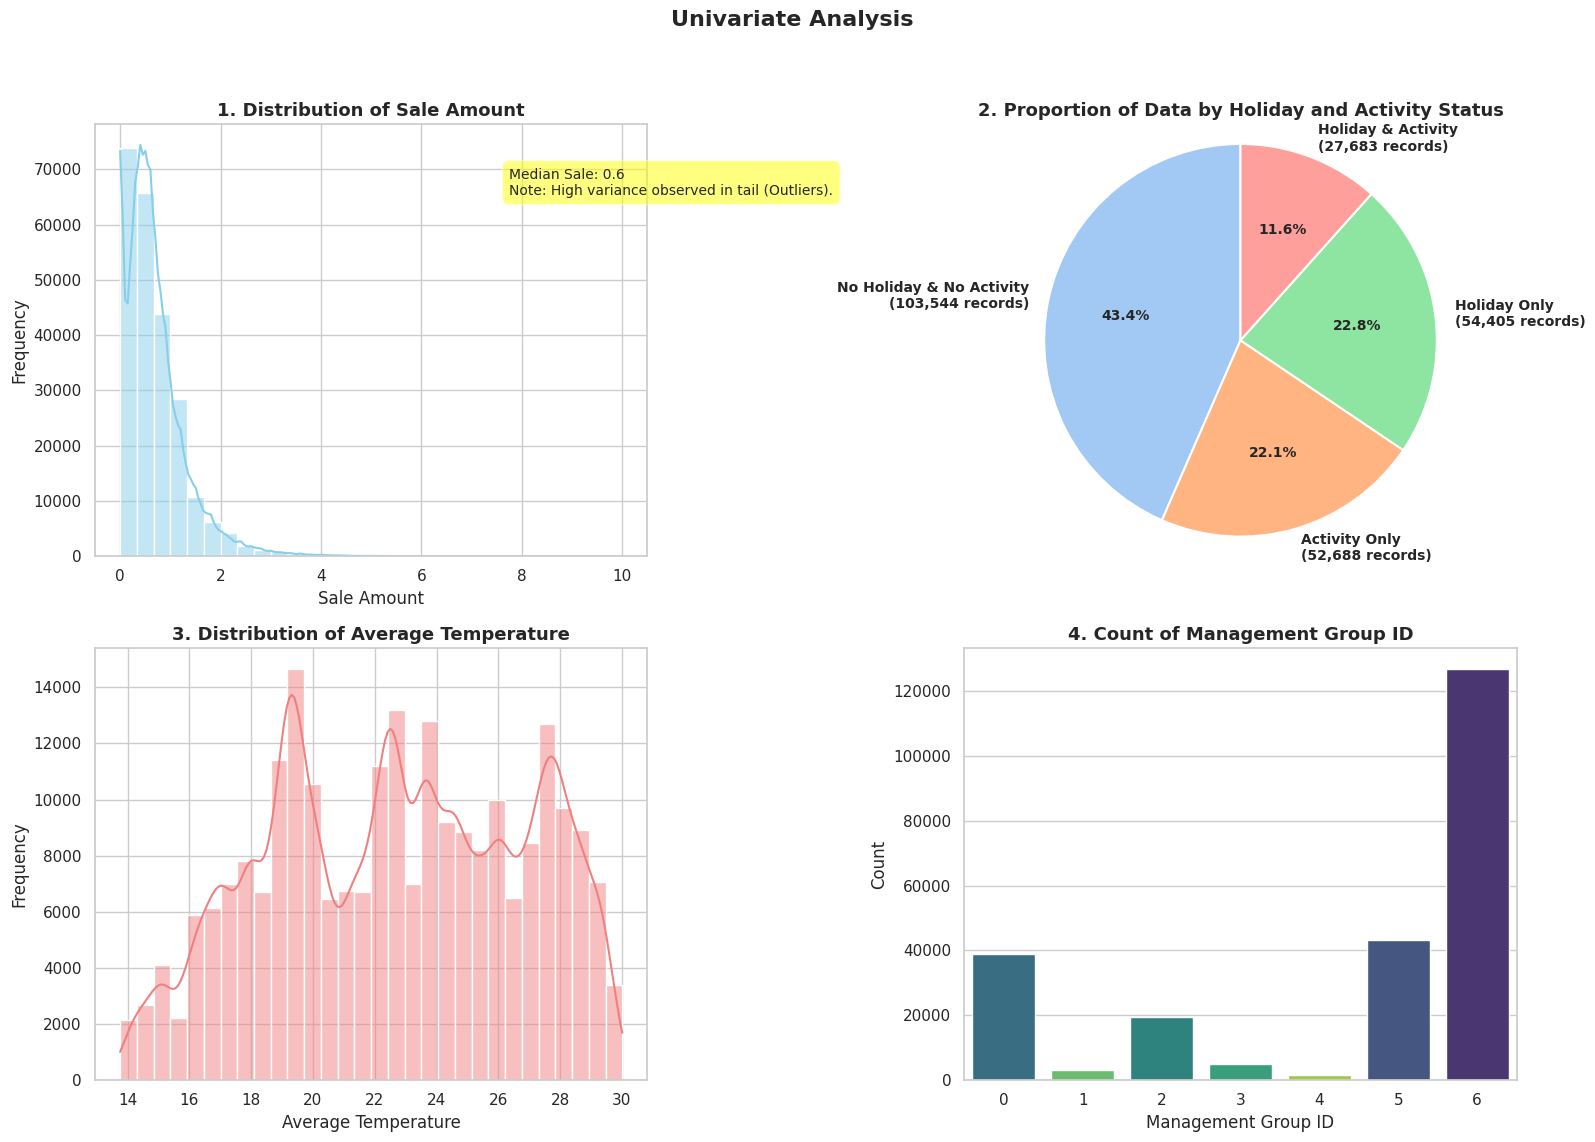

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Univariate Analysis', fontsize=16, fontweight='bold')

# Plot 1: Distribution of Sale Amount
sns.histplot(df_eda['sale_amount'], kde=True, ax=axes[0, 0], bins=30, color='skyblue')
axes[0, 0].set_title('1. Distribution of Sale Amount', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Sale Amount')
axes[0, 0].set_ylabel('Frequency')
median_sale = df_eda['sale_amount'].median()
axes[0, 0].text(0.75, 0.9, f'Median Sale: {median_sale:.1f}\nNote: High variance observed in tail (Outliers).',
                transform=axes[0, 0].transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

# Plot 2: Pie Chart of Holiday and Activity Flag Contribution
# Calculate counts for each combination
crosstab_data = pd.crosstab(df_eda['holiday_flag'], df_eda['activity_flag'])

# Flatten the crosstab data into a Series for the pie chart
pie_data = pd.Series({
    'Holiday & Activity': crosstab_data.loc[1, 1],
    'Holiday Only': crosstab_data.loc[1, 0],
    'Activity Only': crosstab_data.loc[0, 1],
    'No Holiday & No Activity': crosstab_data.loc[0, 0]
})

# Define a specific order for better readability in pie chart if desired
ordered_labels = [
    'No Holiday & No Activity',
    'Activity Only',
    'Holiday Only',
    'Holiday & Activity'
]
pie_data = pie_data.reindex(ordered_labels)

# Colors for the pie chart
colors = sns.color_palette('pastel')[0:len(pie_data)]

axes[0, 1].pie(
    pie_data.values,
    labels=[f'{label}\n({val:,} records)' for label, val in pie_data.items()],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 10, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0, 1].set_title('2. Proportion of Data by Holiday and Activity Status', fontsize=13, fontweight='bold')
axes[0, 1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# Plot 3: Distribution of Average Temperature
sns.histplot(df_eda['avg_temperature'], kde=True, ax=axes[1, 0], bins=30, color='lightcoral')
axes[1, 0].set_title('3. Distribution of Average Temperature', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Average Temperature')
axes[1, 0].set_ylabel('Frequency')

# Plot 4: Count of Management Group ID
# Calculate value counts and sort them by ID in ascending order
mg_id_counts = df_eda['management_group_id'].value_counts()
mg_id_order_ascending = sorted(df_eda['management_group_id'].unique()) # Sort by ID ascending

# Create a color palette based on the number of unique management_group_ids
palette = sns.color_palette("viridis", n_colors=len(mg_id_order_ascending))

# Map palette colors to the management_group_ids based on their counts (highest count = darkest color)
# To ensure high counts are dark, we need to sort `mg_id_counts` descending and apply the palette.
# Then, when plotting, use the original `mg_id_order_ascending` for bar order and map colors from the `color_map`.
mg_id_sorted_by_count_desc = mg_id_counts.sort_values(ascending=False).index.tolist()
color_map_by_count = {id_val: palette[i] for i, id_val in enumerate(mg_id_sorted_by_count_desc)}

# Now create a list of colors for the ascending order based on the `color_map_by_count`
colors_for_ascending_order = [color_map_by_count[x] for x in mg_id_order_ascending]

sns.countplot(x='management_group_id', data=df_eda, ax=axes[1, 1],
              order=mg_id_order_ascending, # Order bars by ID ascending
              palette=colors_for_ascending_order, # Apply colors according to the ascending order
              hue='management_group_id', legend=False)
axes[1, 1].set_title('4. Count of Management Group ID', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Management Group ID')
axes[1, 1].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

2 biến

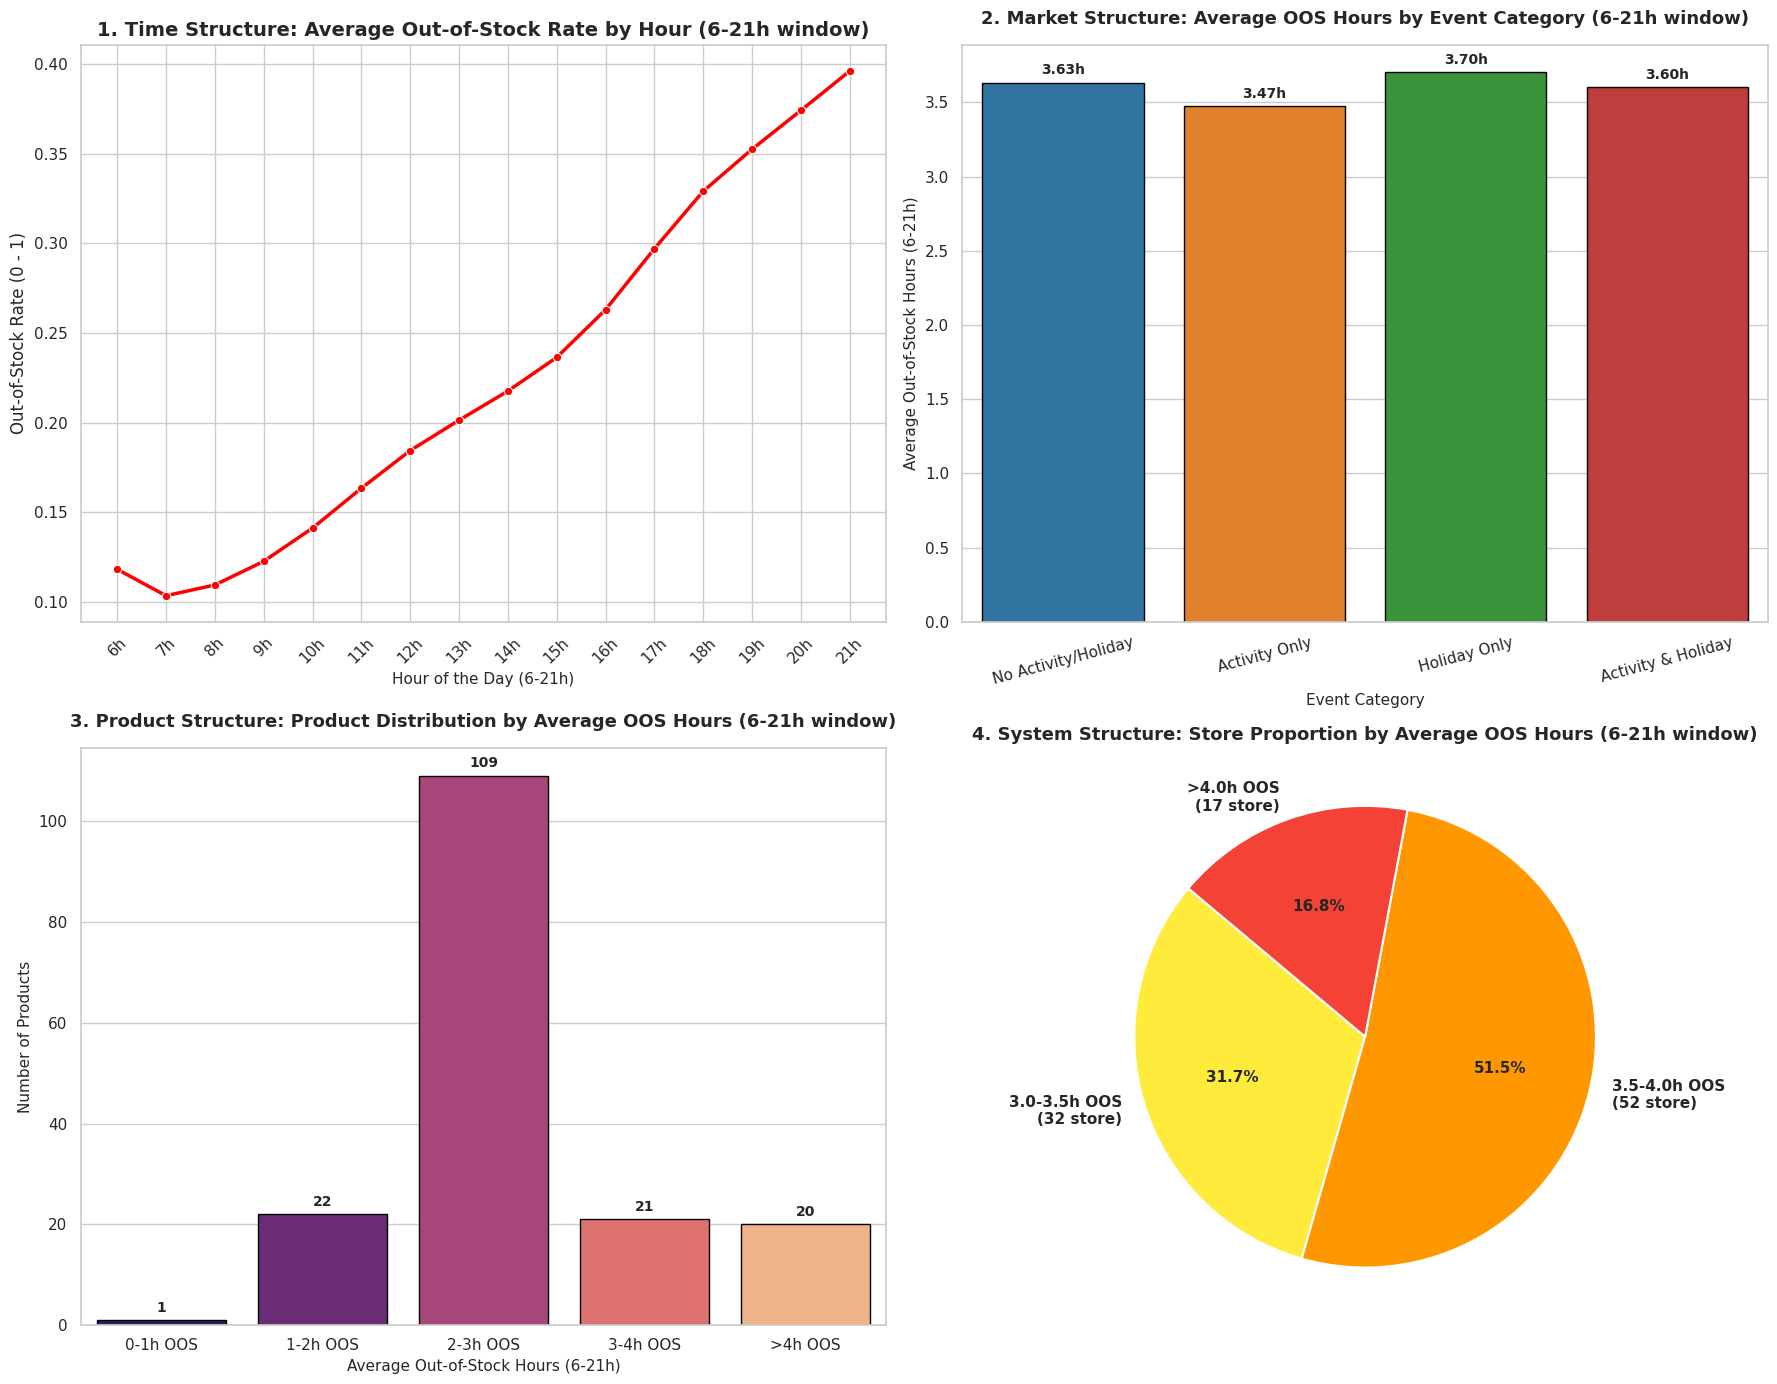

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported
import ast

df = df_city_3.copy()

# Xử lý datetime
df['dt'] = pd.to_datetime(df['dt'])
df['day_of_week'] = df['dt'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)

def safe_eval(x):
    # The 'hours_stock_status' column appears to already contain actual list objects
    # or numpy arrays from the initial dataset loading.
    # Applying ast.literal_eval to a list/array object raises a TypeError.
    # This function is now modified to handle various input types more robustly.
    if isinstance(x, list): # If it's already a list, return it as is
        return x
    if isinstance(x, np.ndarray): # If it's a numpy array, convert it to a list
        return x.tolist()
    if isinstance(x, str): # If it's a string, try to evaluate it as a literal
        try: return ast.literal_eval(x)
        except: pass # If evaluation fails, fall through to default
    return [0]*24 # Default fallback for any unhandled or erroneous data

df['hours_stock_status'] = df['hours_stock_status'].apply(safe_eval)

# Calculate in-stock hours for the 6-21 window (indices 6 to 21)
# 0 means in-stock, 1 means out-of-stock. We count 0s in the slice [6:22] (hours 6-21 inclusive)
df['stock_hour6_21_cnt'] = df['hours_stock_status'].apply(lambda x: sum(1 for status in x[6:22] if status == 0))

# The total number of hours in the 6-21 window is 21 - 6 + 1 = 16 hours.
total_hours_in_window_new = 16

hours_df = pd.DataFrame(df['hours_stock_status'].tolist(), columns=[f'{i}h' for i in range(24)])

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Time Structure: Average Out-of-Stock Rate by Hour (6-21h window)
# Filter hours_df for the 6-21 hour window (columns '6h' through '21h')
hourly_oos_rate = hours_df[[f'{i}h' for i in range(6, 22)]].mean()
sns.lineplot(x=hourly_oos_rate.index, y=hourly_oos_rate.values, marker='o', color='red', linewidth=2.5, ax=axes[0, 0])
axes[0, 0].set_title('1. Time Structure: Average Out-of-Stock Rate by Hour (6-21h window)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Hour of the Day (6-21h)', fontsize=11)
axes[0, 0].set_ylabel('Out-of-Stock Rate (0 - 1)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Market Structure: Average OOS Hours by Event Category
# Calculate OOS hours per record (product-store-day) for the 6-21h window
df['oos_hours_per_record'] = total_hours_in_window_new - df['stock_hour6_21_cnt']

# Define event categories
def get_event_category(row):
    if row['activity_flag'] == 1 and row['holiday_flag'] == 1:
        return 'Activity & Holiday'
    elif row['activity_flag'] == 1 and row['holiday_flag'] == 0:
        return 'Activity Only'
    elif row['activity_flag'] == 0 and row['holiday_flag'] == 1:
        return 'Holiday Only'
    else:
        return 'No Activity/Holiday'

df['event_category'] = df.apply(get_event_category, axis=1)

# Define a specific order for the categories for better visualization
event_category_order = [
    'No Activity/Holiday',
    'Activity Only',
    'Holiday Only',
    'Activity & Holiday'
]

# Calculate average OOS hours per event category, reindex to ensure order
avg_oos_by_event = df.groupby('event_category')['oos_hours_per_record'].mean().reindex(event_category_order)

# Create the bar plot
sns.barplot(
    x=avg_oos_by_event.index,
    y=avg_oos_by_event.values,
    palette='tab10',
    hue=avg_oos_by_event.index,
    legend=False,
    edgecolor='black',
    ax=axes[0, 1]
)

# Add annotations to the bars
for i, val in enumerate(avg_oos_by_event.values):
    axes[0, 1].text(i, val + (max(avg_oos_by_event.values)*0.01), f'{val:.2f}h',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0, 1].set_title('2. Market Structure: Average OOS Hours by Event Category (6-21h window)', fontsize=13, fontweight='bold', pad=15)
axes[0, 1].set_xlabel('Event Category', fontsize=11)
axes[0, 1].set_ylabel('Average Out-of-Stock Hours (6-21h)', fontsize=11)
axes[0, 1].tick_params(axis='x', rotation=15)

# Plot 3: Product Structure: Product Distribution by Average OOS Hours
# Use the new total_hours_in_window and stock_hour6_21_cnt
product_instock_hours = df.groupby('product_id')['stock_hour6_21_cnt'].mean().reset_index()
product_oos = product_instock_hours.copy()
product_oos['avg_oos_hours'] = total_hours_in_window_new - product_oos['stock_hour6_21_cnt'] # Correctly calculate OOS hours

# Adjusted bins and labels for a 16-hour window, using integer boundaries as requested.
# Observed range for product_oos['avg_oos_hours'] is approx 1.1h to 4.0h
product_oos_bins = [0, 1, 2, 3, 4, np.inf]
product_oos_labels = ['0-1h OOS', '1-2h OOS', '2-3h OOS', '3-4h OOS', '>4h OOS']

product_oos['oos_segment'] = pd.cut(product_oos['avg_oos_hours'], bins=product_oos_bins, labels=product_oos_labels)

product_segment_counts = product_oos['oos_segment'].value_counts().reindex(product_oos_labels, fill_value=0)

sns.barplot(
    x=product_segment_counts.index,
    y=product_segment_counts.values,
    palette='magma',
    hue=product_segment_counts.index,
    legend=False,
    edgecolor='black',
    ax=axes[1, 0]
)

for i, val in enumerate(product_segment_counts.values):
    axes[1, 0].text(i, val + (max(product_segment_counts.values)*0.01), f'{val:,}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1, 0].set_title('3. Product Structure: Product Distribution by Average OOS Hours (6-21h window)', fontsize=13, fontweight='bold', pad=15)
axes[1, 0].set_xlabel('Average Out-of-Stock Hours (6-21h)', fontsize=11)
axes[1, 0].set_ylabel('Number of Products', fontsize=11)

# Plot 4: System Structure: Store Proportion by Average OOS Hours
# Use the new total_hours_in_window and stock_hour6_21_cnt
avg_instock_hours_per_store = df.groupby('store_id')['stock_hour6_21_cnt'].mean()
avg_oos_per_store = total_hours_in_window_new - avg_instock_hours_per_store # Correctly calculate OOS hours for stores

# Adjusted bins and labels for a 16-hour window, using 0.5h increments as requested.
# Observed range for avg_oos_per_store is approx 3.3h to 4.0h
bins = [3.0, 3.5, 4.0, np.inf]
labels = ['3.0-3.5h OOS', '3.5-4.0h OOS', '>4.0h OOS']
avg_oos_per_store_binned = pd.cut(avg_oos_per_store, bins=bins, labels=labels, right=True) # Use avg_oos_per_store for segmentation

pie_data = avg_oos_per_store_binned.value_counts().reindex(labels, fill_value=0)

colors = ['#ffeb3b', '#ff9800', '#f44336', '#d32f2f']

axes[1, 1].pie(
    pie_data.values,
    labels=[f"{label}\n({val} store)" for label, val in zip(pie_data.index, pie_data.values)], # Use updated labels
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 11, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1, 1].set_title('4. System Structure: Store Proportion by Average OOS Hours (6-21h window)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

bieeu do 3 in ra top 10 product co ti le het hang
bieu do 4 in ra kha nang het hang cua cac yeu to thoi tiet

Create file

In [33]:
import numpy as np

output_filename = "freshretailnet_city_03_dataset.csv"

df_city_3_for_export = df_city_3.copy()

for col in ['hours_sale', 'hours_stock_status']:
    if col in df_city_3_for_export.columns and df_city_3_for_export[col].apply(lambda x: isinstance(x, np.ndarray)).any():
        df_city_3_for_export[col] = df_city_3_for_export[col].apply(lambda x: str(x.tolist()))

df_city_3_for_export.to_csv(output_filename, index=False)
print(f"DataFrame saved to {output_filename}")

DataFrame saved to freshretailnet_city_03_dataset.csv


END